In [1]:
#1. Data Loading and Inspection

from google.colab import files
uploaded = files.upload()

Saving q1_heart_disease.csv to q1_heart_disease (1).csv


In [2]:
import pandas as pd

df = pd.read_csv('q1_heart_disease.csv')

In [3]:
df.head()
df.shape
df.dtypes

,0
age,int64
sex,int64
chest_pain_type,object
resting_bp,float64
cholesterol,float64
fasting_bs,int64
resting_ecg,object
max_hr,int64
exercise_angina,int64
oldpeak,float64


In [4]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


# 2. Exploratory Data Analysis
**Exploratory Data Analysis (EDA) is the process of analysing and visualising data to understand its patterns, relationships, and distributions. It helps in identifying important features and preparing the data for machine learning models.**

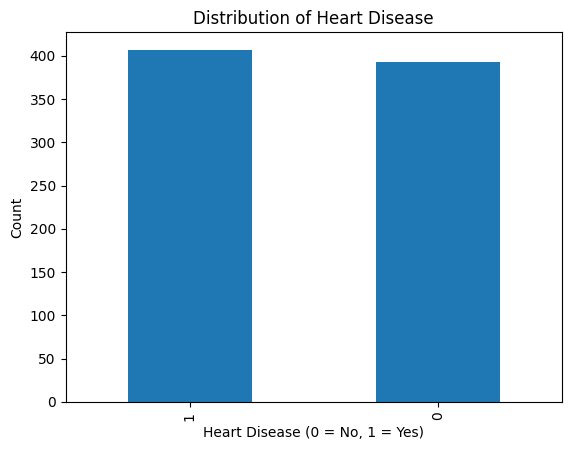

In [5]:
import matplotlib.pyplot as plt

df['heart_disease'].value_counts().plot(kind='bar')
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

**The distribution shows the number of patients with and without heart disease. This helps in understanding whether the dataset is balanced or imbalanced, which can impact model performance.**

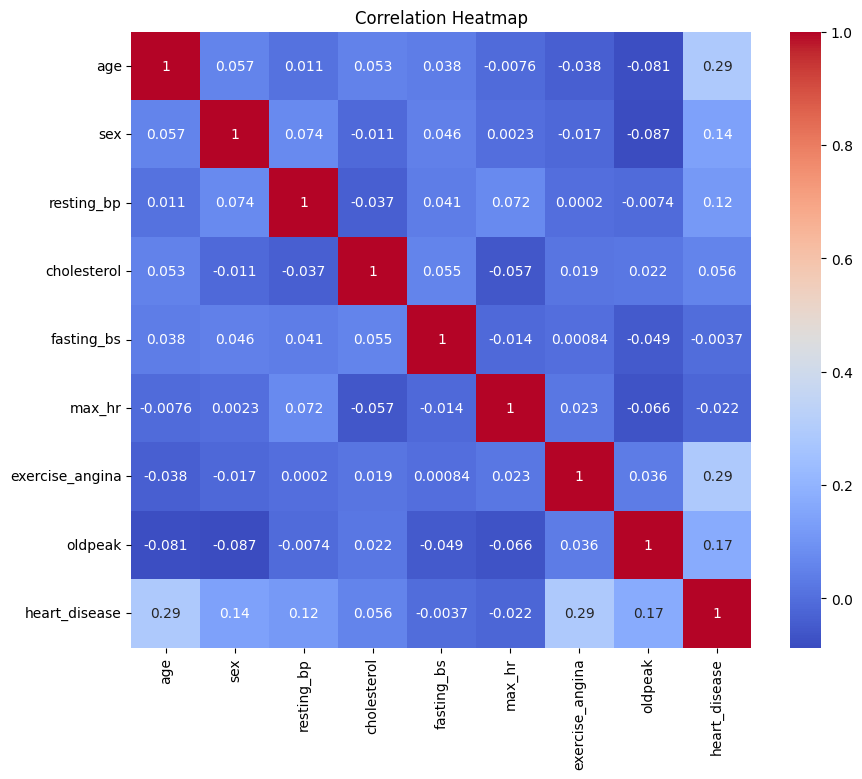

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**The heatmap shows the relationship between numerical features. Features with higher correlation values are more important for predicting heart disease.**

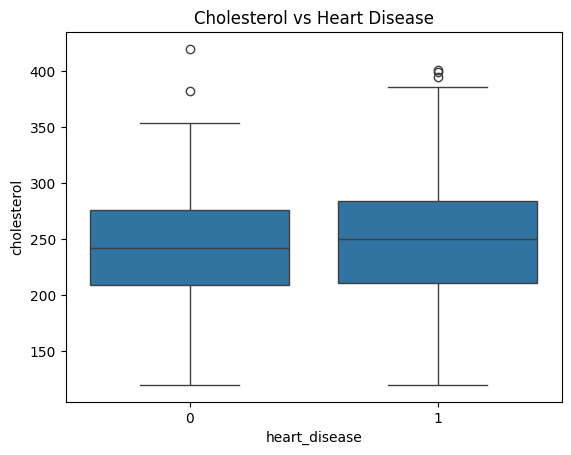

In [7]:
sns.boxplot(x='heart_disease', y='cholesterol', data=df)
plt.title('Cholesterol vs Heart Disease')
plt.show()

**This plot compares cholesterol levels for patients with and without heart disease. It helps identify whether cholesterol is an important factor affecting**

# 3. Data Preprocessing
**Data preprocessing is an essential step in machine learning where raw data is cleaned and transformed into a suitable format for modelling. This includes handling missing values, encoding categorical variables, scaling numerical features, and splitting the dataset into training and testing sets.**

In [8]:
#1. Handle Missing Values

df.fillna(df.median(numeric_only=True), inplace=True)

**Missing values are handled using median imputation, as it is robust to outliers and ensures data consistency.**

In [9]:
#2. One-Hot Encoding

df = pd.get_dummies(df, drop_first=True)

**Categorical variables are converted into numerical format using one-hot encoding so that they can be used in machine learning models.**

In [10]:
#3. Split Features and Target

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [11]:
#4. Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
#5. Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Feature scaling is applied using StandardScaler to ensure all features are on a similar scale, improving model performance.**

#4. Model Training
**In this step, multiple classification models are trained to predict the presence of heart disease. Decision Tree, Random Forest, and Gradient Boosting classifiers are used to compare their performance and identify the most effective mode**

In [13]:
#1. Importing Models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [14]:
#2. Creating Models

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

In [15]:
#3. Train Models

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [16]:
#4. Outputs

print("Decision Tree trained")
print("Random Forest trained")
print("Gradient Boosting trained")

Decision Tree trained
Random Forest trained
Gradient Boosting trained


#5. Model Evaluation
**In this step, the performance of the trained models is evaluated using a confusion matrix and classification metrics such as precision, recall, and F1-score. These metrics provide a better understanding of model performance compared to accuracy alone**


In [17]:
#Evaluating All Models Together

from sklearn.metrics import confusion_matrix, classification_report

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    print(f"\n{name}")

    y_pred = model.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Decision Tree
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
     

Among the three models, Random Forest Classifier performs the best. It achieves the highest F1-score (approximately 0.80) along with strong precision and recall values for both classes.

The Decision Tree model shows lower performance with an F1-score around 0.70, indicating weaker predictive ability. Gradient Boosting performs better than Decision Tree but still falls slightly below Random Forest.

Therefore, Random Forest is selected as the best model because it provides the most balanced and accurate predictions based on precision, recall, and F1-score rather than relying only on accuracy

#6. Hyperparameter Tuning
**Hyperparameter tuning is performed to improve model performance by selecting the best combination of parameters. GridSearchCV is used to systematically evaluate different parameter values and identify the optimal configuration.**

In [18]:
#1. Grid Search Setup

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

In [19]:
#2. Apply GridSearchCV

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [100, 200]})

In [20]:
#3. Best Parameters

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [21]:
#4. Evaluate Tuned Model

best_model = grid.best_estimator_

from sklearn.metrics import confusion_matrix, classification_report

y_pred = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[59 20]
 [17 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        79
           1       0.76      0.79      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



After applying GridSearchCV, the best parameters identified for the Random Forest model were n_estimators = 200 and max_depth = None.
The tuned model shows similar performance to the baseline model, indicating that the original model was already well-optimized.
This demonstrates that hyperparameter tuning helps confirm whether further improvements are possible and ensures the model is using optimal parameter settings